In [17]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [18]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [19]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/5.flexible_reps")

## Goal coding (allocentric)

In [20]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import events
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

In [21]:
reload(gc)
reload(events)
reload(mp)


def plot_single_unit_trial_aligned(cluster_unique_ID, save_label=False):
    """
    Plots the average and goal-stratified trial aligned tuning curves for a given cluster,
    with maze color key (returns separate figs that can be saved separately) and assembled
    into full figure.
    """
    Cluster = gc.get_cluster(cluster_unique_ID)
    f1, ax1 = plt.subplots(1, 1, figsize=(0.75, 0.75), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": False, "color": "black"}, ax=ax1)
    ax1.set_xticklabels([])
    ax1.set_ylabel("Hz")

    f2, ax2 = plt.subplots(1, 1, figsize=(3, 1.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True, "smooth_SD": 15}, ax=ax2)

    f3, axes3 = plt.subplots(1, 2, figsize=(3, 1.5), clear=True)
    Cluster.plot_tuning(feature="event_aligned", feature_kwargs={"goal_stratified": True, "smooth_SD": 10}, ax=axes3)

    goals = Cluster.goals
    simple_maze = mr.get_simple_maze(Cluster.maze_name)
    f4, ax3 = plt.subplots(1, 1, figsize=(1.5, 1.5), clear=True)
    mp.plot_maze_legend(simple_maze, goals, ax=ax3)

    if save_label:
        goal_strat_neurons_path = FIG_SAVE_PATH / "example_neurons"
        goal_strat_neurons_path.mkdir(exist_ok=True, parents=True)
        f1.savefig(goal_strat_neurons_path / f"{save_label}_inset.pdf")
        f2.savefig(goal_strat_neurons_path / f"{save_label}_trial_aligned_tuning.pdf")
        f3.savefig(goal_strat_neurons_path / f"{save_label}_event_aligned_tuning.pdf")
        f4.savefig(goal_strat_neurons_path / f"{save_label}_legend.pdf")
    else:
        return f1, f2, f3, f4

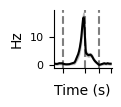

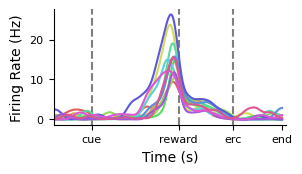

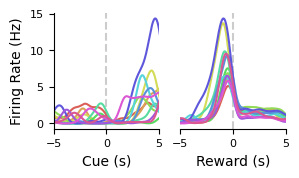

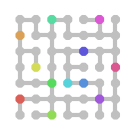

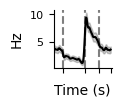

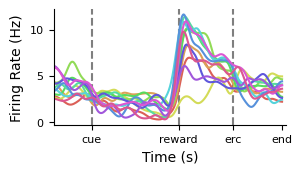

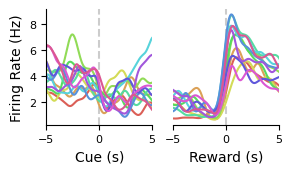

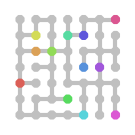

In [22]:
plot_single_unit_trial_aligned("m2.2022-07-04.maze_cluster65", save_label="goal_strat_example_1")
plot_single_unit_trial_aligned("m3.2022-07-17.maze_cluster45", save_label="goal_strat_example_2")

In [23]:
from GridMaze.analysis.goal_coding import simple_decoding as sd

In [24]:
event_aligned_df = sd.get_event_aligned_decoding_summary(verbose=False)
trial_aligned_df = sd.get_trial_aligned_decoding_summary(verbose=False)

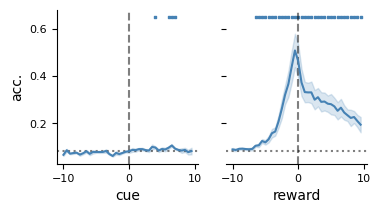

In [25]:
f, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
sd.plot_event_aligned_decoding(
    event_aligned_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    color="steelblue",
    y_max=0.65,
    axes=axes,
)
f.savefig(FIG_SAVE_PATH / "goal_decoding.pdf")

In [26]:
from GridMaze.analysis.event_aligned import delta_distance_to_goal as ddg

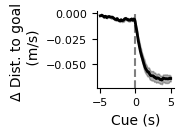

In [27]:
f, ax = plt.subplots(1, 1, figsize=(1, 1), clear=True)
ddg.plot_cross_subject_rate_of_change_of_distance_to_goal(ax=ax, window_length=5, smooth_SD=6, color="black")
f.savefig(FIG_SAVE_PATH / "distance_to_goal_rate_of_change.pdf")

## Distance to goal coding

In [28]:
# plot some individual units
from GridMaze.analysis.cluster_tuning import distance_to_goal as dtg
from GridMaze.analysis.core import get_clusters as gc
import numpy as np
from cmap import Colormap


def plot_example_neurons(clusters, ax, cmap="hls"):
    cm = Colormap(cmap)
    colors = cm(np.linspace(0, 1, len(clusters)))
    for cluster, c in zip(clusters, colors):
        Cluster = gc.get_cluster(cluster)
        Cluster.plot_tuning(feature="distance_to_goal", feature_kwargs={"normalisation": "max", "color": c}, ax=ax)
    ax.set_xlabel("Distance to Goal (m)")
    ax.set_ylabel("Norm. Firing Rate")
    return

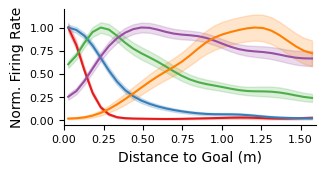

In [29]:
pos_example_clusters = [
    "m2.2022-07-03.maze_cluster43",
    "m3.2022-07-02.maze_cluster44",
    "m2.2022-07-03.maze_cluster9",
    "m7.2022-07-02.maze_cluster55",
    "m7.2022-07-25.maze_cluster73",
]

f1, ax = plt.subplots(1, 1, figsize=(3.25, 1.5))
plot_example_neurons(pos_example_clusters, ax, cmap="colorbrewer:set1_5")
f1.savefig(FIG_SAVE_PATH / "distance_neurons_1.pdf")

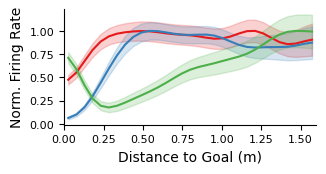

In [30]:
neg_example_clusters = [
    "m7.2022-07-10.maze_cluster8",
    "m2.2022-07-13.maze_cluster86",
    "m7.2022-07-10.maze_cluster53",
]
f2, ax = plt.subplots(1, 1, figsize=(3.25, 1.5))
plot_example_neurons(neg_example_clusters, ax, cmap="colorbrewer:set1_3")
f2.savefig(FIG_SAVE_PATH / "distance_neurons_2.pdf")

In [50]:
from GridMaze.analysis.distance_to_goal import population_tuning as pt

population_tuning_df = pt.get_population_tuning_df(late_sessions=False)

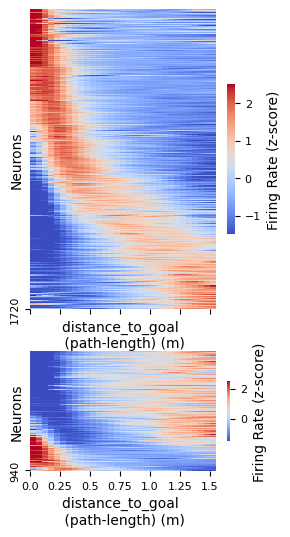

In [ ]:
reload(pt)
f, axes = plt.subplots(2, 1, figsize=(3, 6), height_ratios=[5, 2], sharex=True)
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="pos", ax=axes[0], cmap="coolwarm", v_range=(-1.5, 2.5))
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="neg", ax=axes[1], cmap="coolwarm", v_range=(-1.5, 2.5))
f.savefig(FIG_SAVE_PATH / "distance_tuning_heatmaps.pdf")

In [ ]:
from GridMaze.analysis.distance_to_goal import distance_metrics as dm

cpd_summary_df = dm.get_distance_metric_CPD_summary_df(subfolder="all_trials")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 distance_to_goal.euclidean vs distance_to_goal.geodesic: t-stat: -4.559, p-value: 0.006
 distance_to_goal.euclidean > 0: t-stat: -0.158, p-value: 0.880
 distance_to_goal.geodesic > 0: t-stat: 5.306, p-value: 0.003


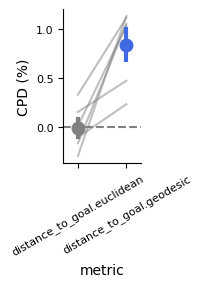

In [ ]:
reload(dm)
f, ax = plt.subplots(1, 1, figsize=(1, 2))
dm.plot_cross_subject_CPD_comparison(
    cpd_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    maze_names=["maze_1", "maze_2"],
    late_sessions=False,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "geo_euc_CPD_comparison.pdf")

In [ ]:
from GridMaze.analysis.distance_to_goal import logreg_decoder as ld

results_df = ld.load_decoding_results(subfolder="all_dist")

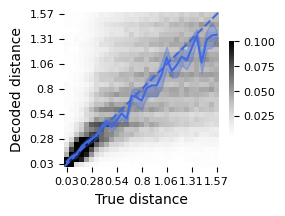

In [ ]:
reload(ld)
f, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
ld.plot_distance_decoding_probs(results_df, moving_only=True, ax=ax)
f.savefig(FIG_SAVE_PATH / "distance_decoding_probs.pdf")

## Supp. Goal coding

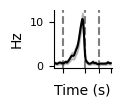

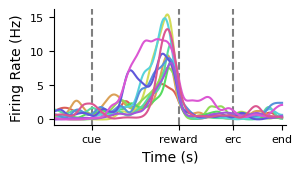

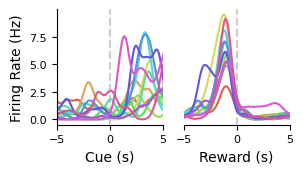

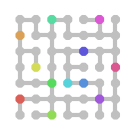

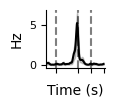

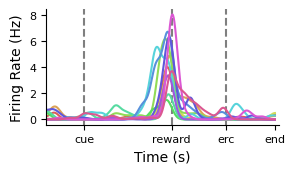

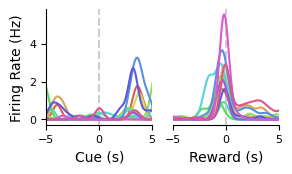

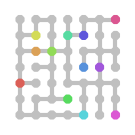

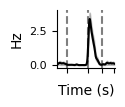

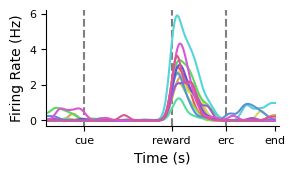

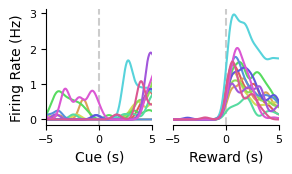

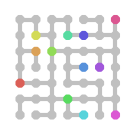

In [33]:
plot_single_unit_trial_aligned("m2.2022-07-04.maze_cluster114", save_label="goal_strat_example_3")
plot_single_unit_trial_aligned("m2.2022-07-17.maze_cluster50", save_label="goal_strat_example_4")
plot_single_unit_trial_aligned("m6.2022-07-05.maze_cluster134", save_label="goal_strat_example_5")

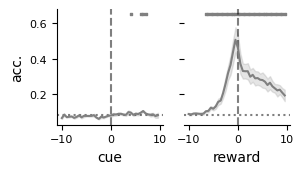

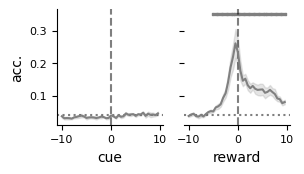

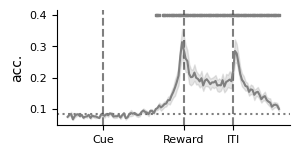

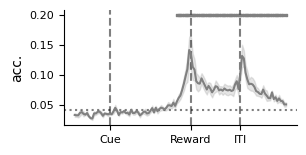

In [44]:
reload(sd)
f1, axes = plt.subplots(1, 2, figsize=(3, 1.5), sharey=True)
sd.plot_event_aligned_decoding(
    event_aligned_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    color="grey",
    y_max=0.65,
    axes=axes,
)
f1.savefig(FIG_SAVE_PATH / "simple_decoding_event_aligned_subsets.pdf")

f2, axes = plt.subplots(1, 2, figsize=(3, 1.5), sharey=True)
sd.plot_event_aligned_decoding(
    event_aligned_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["all"],
    chance=1 / 24,
    color="grey",
    y_max=0.35,
    axes=axes,
)
f2.savefig(FIG_SAVE_PATH / "simple_decoding_event_aligned_all.pdf")


f3, ax = plt.subplots(1, 1, figsize=(3, 1.5), clear=True)
sd.plot_trial_aligned_decoding(
    trial_aligned_df,
    maze_names=["maze_1", "maze_2", "rooms_maze"],
    goal_subsets=["subset_1", "subset_2"],
    color="grey",
    chance=1 / 12,
    y_max=0.4,
    ax=ax,
)
f3.savefig(FIG_SAVE_PATH / "simple_decoding_trial_aligned_subsets.pdf")


f4, ax = plt.subplots(1, 1, figsize=(3, 1.5), clear=True)
sd.plot_trial_aligned_decoding(
    trial_aligned_df,
    maze_names=["maze_1", "maze_2", "rooms_maze"],
    goal_subsets=["all"],
    color="grey",
    chance=1 / 24,
    y_max=0.2,
    ax=ax,
)
f4.savefig(FIG_SAVE_PATH / "simple_decoding_trial_aligned_all.pdf")

In [38]:
from GridMaze.analysis.goal_coding import place_decoding_control as pdc

In [39]:
reload(pdc)
spatial_control_df = pdc.get_spatial_goal_decoding_control_summary(verbose=False)

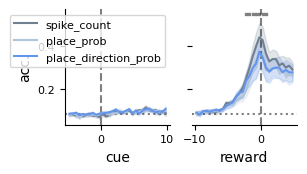

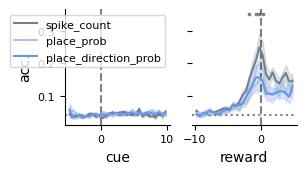

In [45]:
reload(pdc)
f1, axes = plt.subplots(1, 2, figsize=(3, 1.5), sharey=True)
pdc.plot_event_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    cue_window=(-5, 10),
    reward_window=(-10, 5),
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("slategrey", "lightsteelblue", "cornflowerblue"),
    y_max=0.55,
    axes=axes,
)
f1.savefig(FIG_SAVE_PATH / "spatial_control_event_aligned_subsets.pdf")

f2, axes = plt.subplots(1, 2, figsize=(3, 1.5), sharey=True)
pdc.plot_event_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["all"],
    chance=1 / 24,
    cue_window=(-5, 10),
    reward_window=(-10, 5),
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("slategrey", "lightsteelblue", "cornflowerblue"),
    y_max=0.35,
    axes=axes,
)
f2.savefig(FIG_SAVE_PATH / "spatial_control_event_aligned_all.pdf")

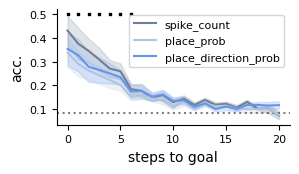

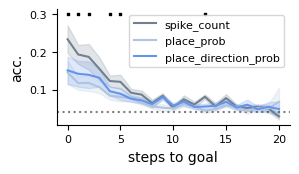

In [46]:
f, ax = plt.subplots(1, 1, figsize=(3, 1.5), sharey=True)
pdc.plot_distance_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    max_distance=20,
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("slategrey", "lightsteelblue", "cornflowerblue"),
    residuals_comparison=["spike_count", "place_prob"],
    y_max=0.5,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "spatial_control_distance_aligned_subsets.pdf")

f2, ax = plt.subplots(1, 1, figsize=(3, 1.5), sharey=True)
pdc.plot_distance_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["all"],
    chance=1 / 24,
    max_distance=20,
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("slategrey", "lightsteelblue", "cornflowerblue"),
    residuals_comparison=["spike_count", "place_prob"],
    y_max=0.3,
    ax=ax,
)
f2.savefig(FIG_SAVE_PATH / "spatial_control_distance_aligned_all.pdf")

In [43]:
from GridMaze.analysis.goal_coding import pseudo_trial_decoding as ptd

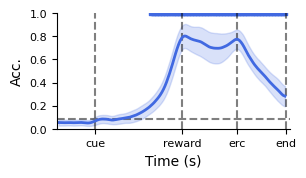

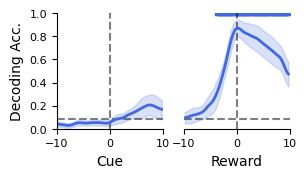

In [47]:
f, ax = plt.subplots(1, 1, figsize=(3, 1.5), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="trial",
    decoder="logreg",
    bootstrap_method="input",
    color="royalblue",
    sig_color="royalblue",
    sig_pos=1.0,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding_trial_aligned_linear.pdf")

f2, axes = plt.subplots(1, 2, figsize=(3, 1.5), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="event",
    decoder="logreg",
    bootstrap_method="input",
    color="royalblue",
    sig_color="royalblue",
    sig_pos=1.0,
    ax=axes,
)
f2.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding_event_aligned_linear.pdf")

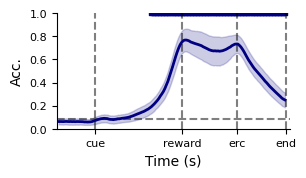

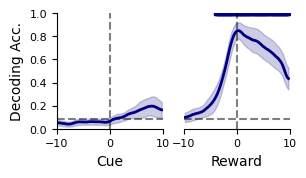

In [48]:
f, ax = plt.subplots(1, 1, figsize=(3, 1.5), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="trial",
    decoder="mlp_torch",
    bootstrap_method="input",
    color="navy",
    sig_color="navy",
    sig_pos=1.0,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding_trial_aligned_nonlinear.pdf")

f2, axes = plt.subplots(1, 2, figsize=(3, 1.5), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="event",
    decoder="mlp_torch",
    bootstrap_method="input",
    color="navy",
    sig_color="navy",
    sig_pos=1.0,
    ax=axes,
)
f2.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding_event_aligned_nonlinear.pdf")

## Supp. Distance to goal 

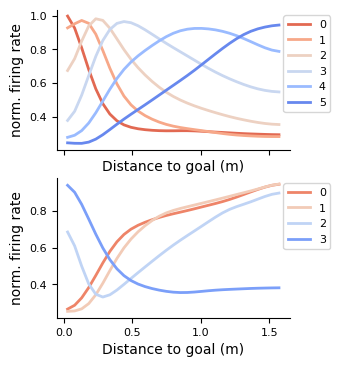

In [55]:
reload(pt)
f, axes = plt.subplots(2, 1, figsize=(3, 4), sharex=True)
pt.plot_population_quantiles(
    population_tuning_df, sign="pos", normalisation_method="max", n_quantiles=6, cmap="coolwarm_r", ax=axes[0]
)
pt.plot_population_quantiles(
    population_tuning_df, sign="neg", normalisation_method="max", n_quantiles=4, cmap="coolwarm_r", ax=axes[1]
)
f.savefig(FIG_SAVE_PATH / "distance_tuning_quantiles.pdf")

In [52]:
fit_summary_df = pt.get_tuning_fits_summary_df(late_sessions=False)

gamma_4p vs gaussian_4p: 
 t-stat: 7.322, p-value: 7.447e-04


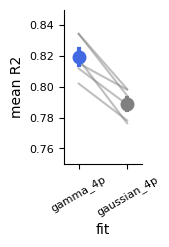

In [56]:
reload(pt)
f, ax = plt.subplots(1, 1, figsize=(1, 2))
pt.plot_cross_subject_curve_fit_comparison(
    fit_summary_df, curve_fits=["gamma_4p", "gaussian_4p"], colors=["royalblue", "grey"], ax=ax
)
ax.set_ylim(0.75, 0.85)
f.savefig(FIG_SAVE_PATH / "curve_fit_comparison.pdf")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 distance_to_goal.euclidean vs distance_to_goal.geodesic: t-stat: -4.559, p-value: 0.006
 distance_to_goal.euclidean > 0: t-stat: -0.158, p-value: 0.880
 distance_to_goal.geodesic > 0: t-stat: 5.306, p-value: 0.003
distance_to_goal.geodesic_vs_distance_to_goal.manhattan: 
 distance_to_goal.manhattan vs distance_to_goal.geodesic: t-stat: -5.180, p-value: 0.004
 distance_to_goal.manhattan > 0: t-stat: -0.471, p-value: 0.657
 distance_to_goal.geodesic > 0: t-stat: 5.172, p-value: 0.004
distance_to_goal.geodesic_vs_distance_to_goal.future: 
 distance_to_goal.future vs distance_to_goal.geodesic: t-stat: -2.473, p-value: 0.056
 distance_to_goal.future > 0: t-stat: -2.824, p-value: 0.037
 distance_to_goal.geodesic > 0: t-stat: 0.038, p-value: 0.971
distance_to_goal.geodesic_vs_progress_to_goal.path_length: 
 progress_to_goal.path_length vs distance_to_goal.geodesic: t-stat: -5.046, p-value: 0.004
 progress_to_goal.path_length > 0: t-st

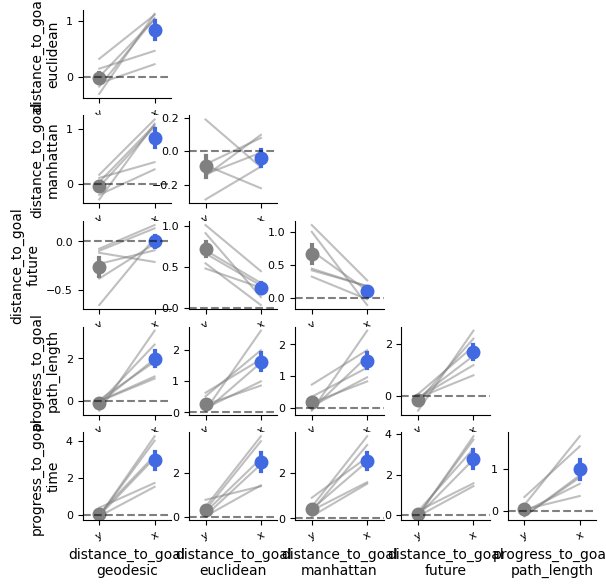

In [57]:
f, axes = plt.subplots(6, 6, figsize=(8, 8))
reload(dm)
dm.plot_pairwise_CPD_cross_subject_comparisons(cpd_summary_df, late_sessions=False, axes=axes)
f.savefig(FIG_SAVE_PATH / "pairwise_CPD_comparisons.pdf")